# Applications of Principal Component Analysis (PCA)

## Import required libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

%matplotlib inline

## Part I: Using PCA to project 2D data onto its principal axes

### Create dataset

<p>Next you'll create a 2-dimensional dataset containing two linearly correlated features. You'll use a bivariate normal distribution.</p>
<p>Both features, X1 and X2, will have zero mean and a covariance given by the (symmetric) covariance matrix:</p>

\begin{pmatrix}
 3 & 2 \\
 2 & 2
\end{pmatrix}

<p>Here, the diagonal elements define the variances of X1 and X2 (3 and 2, respectively), while the off-diagonal element is the covariance (2) between X1 and X2, which expresses how similarly these features vary.</p>

In [2]:
np.random.seed(42)
mean = [0, 0]
cov = [[3, 2], [2, 2]]
X = np.random.multivariate_normal(mean=mean, cov=cov, size=200)

### Exercise

<p>Visualize the relationship between the two features. For example, you can use a scatterplot.</p>

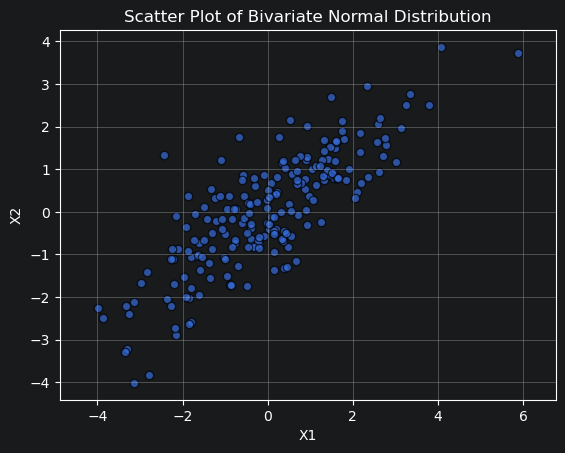

In [3]:
plt.figure()
plt.scatter(X[:, 0], X[:, 1], edgecolor="k", alpha=0.7)
plt.title("Scatter Plot of Bivariate Normal Distribution")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis("equal")
plt.grid(True)

<p>Consider the main direction the data follows in the scatterplot. It's actually the direction of the first principal component. You can use PCA to determine this direction.</p>

### Perform PCA on the dataset

<p>Next, you'll initialize a 2-component PCA model with default parameters and then fit and transform the feature space in one step.</p>

In [4]:
pca = PCA(n_components=2)
pca.fit_transform(X)

array([[-1.04842083e+00, -1.06980963e-01],
       [-1.36011135e+00,  9.96147017e-01],
       [ 5.11856490e-01, -1.85703592e-01],
       [-3.35443240e+00,  5.15279173e-01],
       [ 1.01944843e+00,  3.23656540e-01],
       [ 9.99993608e-01, -3.43827870e-01],
       [-5.15830396e-01, -1.28757105e+00],
       [ 3.69352656e+00, -4.34071204e-01],
       [ 2.17840683e+00,  1.61153249e-01],
       [ 1.94340877e+00, -9.79848064e-01],
       [-3.11831842e+00, -1.44716110e-01],
       [-1.40136620e-01, -9.67741347e-01],
       [ 1.17663747e+00,  3.62976233e-02],
       [ 2.47387460e+00,  1.98959524e-01],
       [ 1.29417872e+00, -2.31456758e-01],
       [ 1.31032255e+00,  1.18809169e+00],
       [ 3.52808486e-02, -7.26407847e-01],
       [-1.75129025e+00, -8.16984783e-01],
       [-4.45442262e-01, -1.31897712e+00],
       [ 2.85114418e+00,  7.68521862e-02],
       [-1.56272391e+00,  1.03075622e-01],
       [ 2.58334834e-01, -2.27572148e-01],
       [ 3.16628576e+00, -5.33254004e-01],
       [ 1.

### Get the principal components from the model

<p>The principal components are the principal axes, represented in feature space coordinates, which align with the directions of maximum variance in your data.</p>

In [5]:
components = pca.components_
components

array([[ 0.78215821,  0.62307987],
       [-0.62307987,  0.78215821]])

<p>The principal components are sorted in decreasing order by their explained variance, which can be expressed as a ratio.</p>

In [6]:
pca.explained_variance_ratio_

array([0.9111946, 0.0888054])

### Display the results

<p>Here, you'll use a scatterplot to display the data points in their original feature space, X1 and X2. You'll also plot the projections of the data points onto their principal component directions.</p>
<p>It's a bit technical, requiring some understanding of linear algebra, but the outcome will be instructive. So let's see how it works.</p>

#### Project the data onto its principal component axes

<p>The projection of the data onto a given principal component yields the coordinates of each of the data points along that component's direction. The new coordinates are given by the dot products of each point's coordinates with the given PCA component.</p>
<p>Specifically, the projections are given by:</p>

In [7]:
projection_pc1 = np.dot(X, components[0])
projection_pc2 = np.dot(X, components[1])

<p>Now that you have these coordinates, you can use them to represent the projections of each data point along the principal directions in the original feature space.</p>

In [8]:
x_pc1 = projection_pc1 * components[0][0]
y_pc1 = projection_pc1 * components[0][1]
x_pc2 = projection_pc2 * components[1][0]
y_pc2 = projection_pc2 * components[1][1]

#### Plot the results

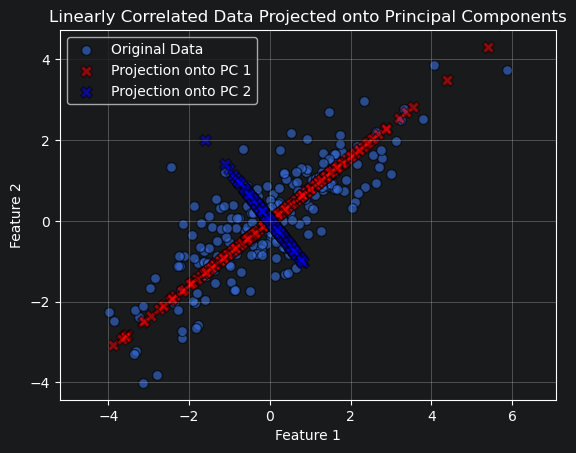

In [9]:
plt.figure()
plt.scatter(X[:, 0], X[:, 1], label="Original Data", ec="k", s=50, alpha=0.6)
plt.scatter(x_pc1, y_pc1, label="Projection onto PC 1", c="r", ec="k", marker="X", s=70, alpha=0.5)
plt.scatter(x_pc2, y_pc2, label="Projection onto PC 2", c="b", ec="k", marker="X", s=70, alpha=0.5)
plt.title("Linearly Correlated Data Projected onto Principal Components")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.axis("equal")
plt.grid(True)

<p>It took some effort but now you can see what the principal coordinates mean. The data varies in two main directions.</p>
<ul>
    <li>The first direction, in red, is aligned in the direction having the widest variation.</li>
    <li>The second direction, in blue, is perpendicular to first and has a lower variance.</li>
</ul>

## Part II. PCA for feature space dimensionality reduction

### Load and preprocess Iris data

In [10]:
iris = datasets.load_iris()
X: np.ndarray = iris.data
y: np.ndarray = iris.target
target_names: np.ndarray = iris.target_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Exercise

<p>1. What are the iris flower's names?</p>

In [11]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

<p>2. Initialize a PCA model and reduce the Iris dataset dimensionality to two components.</p>

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

### Plot the PCA-transformed data in 2D

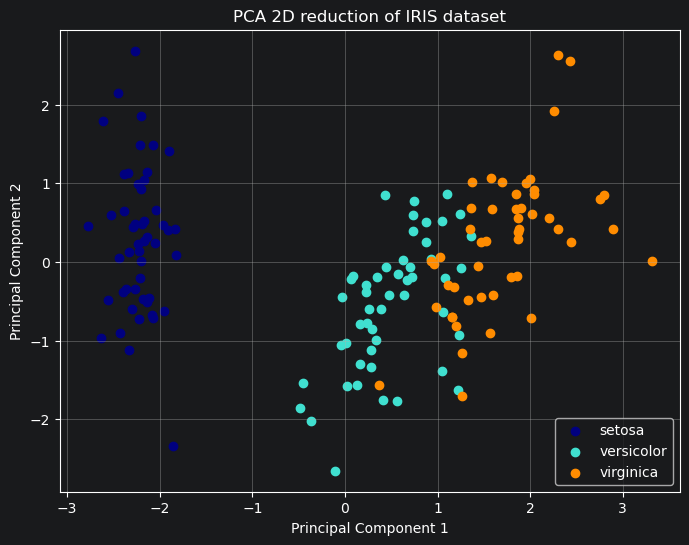

In [13]:
plt.figure(figsize=(8, 6))
colors = ["navy", "turquoise", "darkorange"]
lw = 1

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, lw=lw, label=target_name)

plt.title("PCA 2D reduction of IRIS dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.grid(True)

### Reflection

<p>Examine the plot and consider how well the Iris classes have been separated simply by projecting the feature space down to two principal components.</p>

### Exercise

<p>What percentage of the original feature space variance do these two combined principal components explain?</p>

In [14]:
100 * pca.explained_variance_ratio_.sum()

np.float64(95.81320720000164)

### A deeper look at the explained variances

<p>Reinitialize the PCA model without reducing the dimension. Standardize the Iris data, and fit and transform the scaled data.</p>

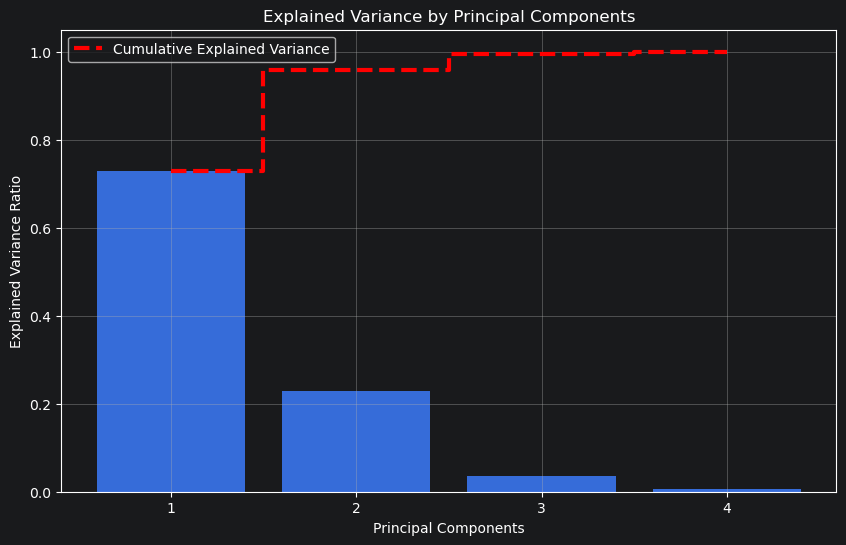

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.bar(x=range(1, len(explained_variance_ratio) + 1), height=explained_variance_ratio, alpha=1)
plt.ylabel("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.title("Explained Variance by Principal Components")

cumulative_variance = np.cumsum(explained_variance_ratio)
plt.step(range(1, 5), cumulative_variance, where="mid", linestyle="--", lw=3, color="red", label="Cumulative Explained Variance")
plt.xticks(range(1, 5))
plt.legend()
plt.grid(True)

<p>Here are some considerations:</p>
<ul>
    <li>What does the red dashed line indicate to you?</li>
    <li>What would you consider doing if your wanted to suppress some noise in your data?</li>
</ul>

****
This is the end of the file.
****